# Assignment 7

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional note:

* You can complete this assignment using either your local machine or Google Colab. Your solution for this assignment should be able to run on the <span style="color:red">FREE version</span> of Google Colab. If you find that you need to upgrade to the paid version, it indicates that there is an inefficiency in your code.
---

#### ``Objectives``
1. Implement a Decision Forest for land cover classification

#### ``Motivation``

Land cover classification using machine learning (ML) techniques is important for several reasons, spanning environmental monitoring, resource management, urban planning, disaster response, and scientific research. 

#### ``Data``

In this assignment, you will use the EuroSAT dataset, consisting of Sentinel-2 RGB satellite images of 10 classes with 27000 labeled and geo-referenced samples. 

The dataset is hosted by [TensorFlow Data Collections](https://www.tensorflow.org/datasets/catalog/eurosat). To avoid any data versioning issues, we have downloaded the data for you (please see below).

`Download` link: [images + labels](https://drive.google.com/file/d/131GuYn092OlWKGopsT8arQoDreneU7SZ/view?usp=share_link). Once you unzip the file, you will see that the name of each subfolder represents the land cover classes.

---

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import random

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import pathlib
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning. 

# FILL IN CODE HERE #
DATA_PATH = "./EuroSAT" # replace with your path

2025-03-03 01:37:54.512986: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-03 01:37:54.516132: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-03 01:37:54.525139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740965874.539675   65269 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740965874.544020   65269 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-03 01:37:54.560702: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

^ make sure to replace DATA_PATH with the path to the directory where you saved the data.

---
### Step 1: Data ingestion

#### <span style="color:chocolate"> Exercise 1 (10 points) </span>

Let's load the 2D images and their corresponding labels. Implement the <span style="color:chocolate">load_data()</span> function below according to the following guidelines:
- to read label and image names: use the <span style="color:chocolate">os</span> library (in particular the <span style="color:chocolate">os.listdir()</span> and <span style="color:chocolate">os.path.join()</span> methods);
- to load an image: use the <span style="color:chocolate">load_image()</span> method (see list of imported libraries);
- to transform images to arrays: use the <span style="color:chocolate">img_to_array()</span> method (see list of imported libraries).

In [2]:
def load_data(path_to_data):
    '''Load 2D images and their corresponding labels
    Parameters:
    path_to_data (str): This is the path to data
    
    Returns:
    images (np.ndarray): A numpy array of shape (N, 64, 64, 3)
    labels (np.ndarray): A numpy array of shape (N)
    
    '''
    ## load images and labels
    # FILL IN CODE HERE #  

    # First create empty lists - which will be turned into np arrs after loading
    img_list = []
    label_list = []

    # Outer: loop through DATA_PATH - EuroSAT folder
    for f in os.listdir(path_to_data):
        # Inner: for each label folder, loop through the img files
        for i in os.listdir(os.path.join(path_to_data, f)):

            # Load the image and specifying the size
            img = load_img(os.path.join(path_to_data, f, i), 
                           target_size=(64, 64))

            # Convert image file to np arr
            img_arr = img_to_array(img) 

            # Add image and label to the list
            img_list.append(img_arr)
            # Split the image file name twice to get to the label, and convert to lowercase for consistency
            label_list.append(i.split('.')[0].split('_')[0].lower())

    # Convert lists to np arrays
    images = np.array(img_list) #/ 255 - I realize we will do this step later
    labels = np.array(label_list)
#LabelEncoder().fit_transform(label_list)

#    labels = np.array(label_list)

    return images, labels

In [3]:
# Load images and labels. Print shapes

images, labels = load_data(DATA_PATH)
print("Shape of images ", images.shape)
print("Shape of labels ", labels.shape)

Shape of images  (27000, 64, 64, 3)
Shape of labels  (27000,)


---
### Step 2: Exploratory data analysis (EDA)

#### <span style="color:chocolate"> Exercise 2 (10 points) </span>

Plot the land cover class distribution. Are the classes balanced?

Note: It's acceptable to plot the distribution of classes before splitting your data into training, validation, and test sets. Doing so does not compromise the "blindness" of the test data. Why?

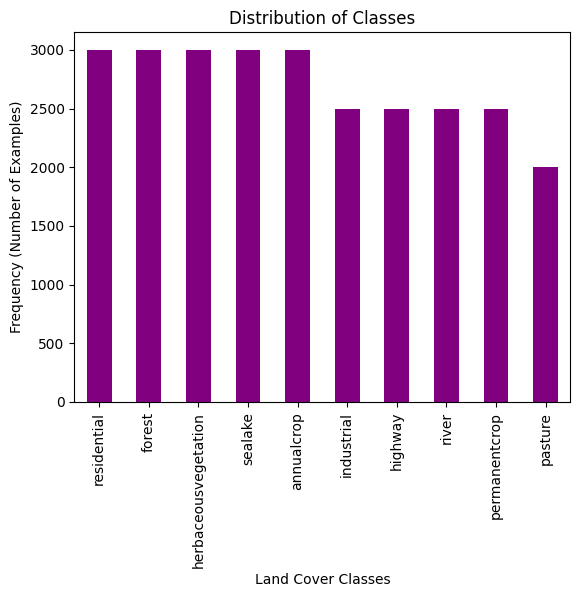

In [4]:
# FILL IN CODE HERE # 

class_counts = pd.Series(labels).value_counts()


fig, ax = plt.subplots()

class_counts.plot(kind='bar', ax=ax,
                  color='purple')

ax.set_xticklabels(class_counts.index, rotation=90)

ax.set_xlabel("Land Cover Classes")
ax.set_ylabel("Frequency (Number of Examples)")
ax.set_title("Distribution of Classes")

plt.show()

##### Comment on class balance: [YOUR ANSWER HERE]

 - Classes are relatively balanced. 5 out of 10 classes have 3000 counts and the rest classes are either 2500 (4 out 10), and 2000 (1 out of 10).
 - Plotting label distribution should not cause information leak: 
    - Random split (on average) will result in the same distribution of labels in both train and test datasets.
    - Such a plot would not reveal individual data points.

#### <span style="color:chocolate"> Exercise 3 (10 points) </span>

Inspect (print) one image from each class. What land classes do you think a Decision Tree classifier is more likely to confuse?

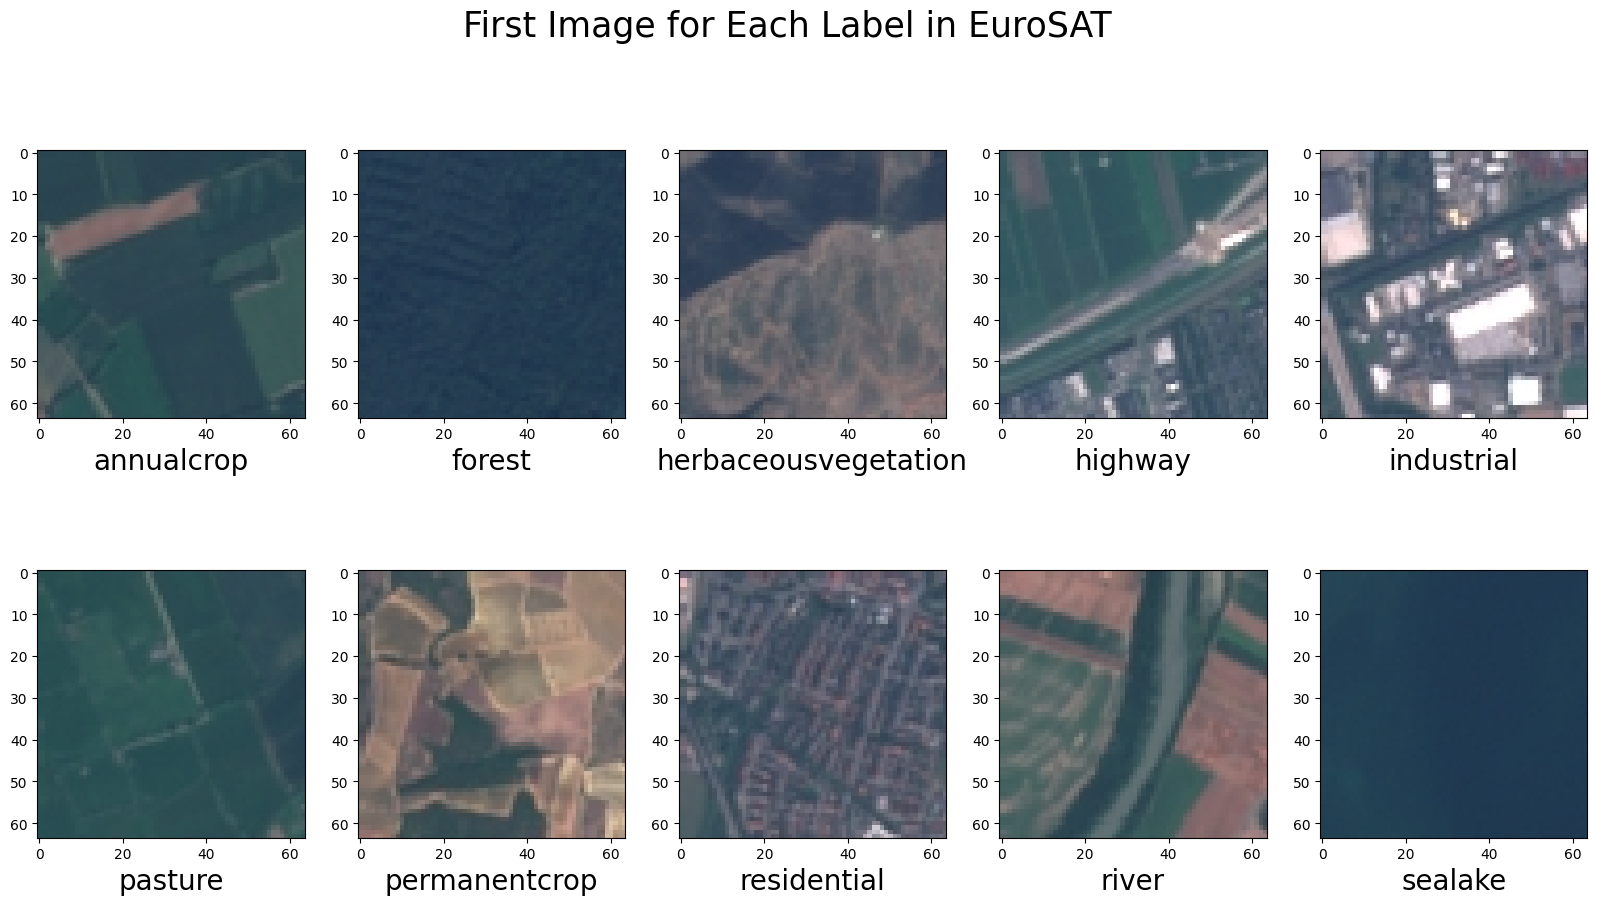

In [5]:
# FILL IN CODE HERE #



first_indice = {label: -1 for label in np.unique(labels)}

# Loop through Y_train_digits to fill in the dict
for idx, label in enumerate(labels):
    if first_indice[label] == -1:
        first_indice[label] = idx
    if all(first_indice[label] != -1 for label in first_indice.keys()):
        break

fig, ax = plt.subplots(2, 5,
                       figsize=(20, 10))

# Loop through each label, and display the first images for each label
ax = ax.flatten()

for idx, key in enumerate(first_indice.keys()):
    ax[idx].imshow(images[first_indice[key],:,:].astype(np.uint8))

    ax[idx].set_xlabel(key,
                            fontsize=20)

fig.suptitle("First Image for Each Label in EuroSAT",
             fontsize=25)
plt.show()        



Most confused land classes: [YOUR ANSWER HERE]

 - Without the benefit of hindsight, I thought annualcrop, forest, pasture, and sealake are the classes that the model would confuse the most.
 - With the benefit of hindsight after completing the homework, I can see residential and highway are classes that can be easily confused.

---
### Step 3: Data preprocessing

Encode labels

In [6]:
encoder = LabelEncoder().fit(list(set(labels))) # fit on unique labels
encoded_labels = encoder.transform(labels) # apply to labels array (will get labels from 0 to 9)
encoded_labels_classes = list(encoder.classes_) # store mapping generated by the encoder

#### <span style="color:chocolate"> Exercise 4 (10 points) </span>

Create train, validation, and test data. Implement the <span style="color:chocolate">split_data()</span> function below according to the following guidelines:
- shuffle images and labels before spliting the data;
- use a 60/20/20 split.

In [7]:
def split_data(images, labels, split):
    '''Split data into train, validation and test sets.
    
    Parameters:
    images  (np.ndarray): Images of shape (N, 64, 64, 3)
    labels (np.ndarray): Labels of shape (N,)   
    split (tuple): 3 values summing to 1 defining split of train, validation and test sets
    
    Returns:
    X_train (np.ndarray): Train images of shape (N_train, 64, 64, 3)
    y_train (np.ndarray): Train labels of shape (N_train,)
    X_val (np.ndarray): Val images of shape (N_val, 64, 64, 3)
    y_val (np.ndarray): Val labels of shape (N_val,)
    X_test (np.ndarray): Test images of shape (N_test, 64, 64, 3)
    y_test (np.ndarray): Test labels of shape (N_test,)
    
    '''
    # NOTE: Each time you run this cell, you'll re-shuffle the data. The ordering will be the same due to the random seed generator 
    tf.random.set_seed(1234)
    np.random.seed(1234)
    
    # shuffle data
    # FILL IN CODE HERE #
    
    # First get indices
    indices = np.arange(images.shape[0]) 

    # Then shuffle indices
    indices_shuffled = np.random.permutation(indices)

    # Next shuffle images and labels 
    images_shuffled = images[indices_shuffled,:,:,:]
    labels_shuffled = labels[indices_shuffled]

    # create data splits
    # FILL IN CODE HERE #


    # Multiply (broadcasting) splits by the number of examples
    split = np.multiply(split, labels.shape[0]).astype(int)

    # Split the data 
    # Note that the data is ALREADY shuffled, so we can just call np.split() to split the data here.
    X_train, X_val, X_test = np.split(images_shuffled, [split[0], split[0] + split[1]])
    y_train, y_val, y_test = np.split(labels_shuffled, [split[0], split[0] + split[1]])

    return X_train, y_train, X_val, y_val, X_test, y_test

In [8]:
# define splits
split = (0.6, 0.2, 0.2)

# create train, val, test sets
X_train, y_train, X_val, y_val, X_test, y_test = split_data(images, encoded_labels, split)

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)

print('Shape of val images ', X_val.shape)
print('Shape of train labels ', y_val.shape)

print('Shape of test images ', X_test.shape)
print('Shape of test labels ', y_test.shape)

Shape of train images  (16200, 64, 64, 3)
Shape of train labels  (16200,)
Shape of val images  (5400, 64, 64, 3)
Shape of train labels  (5400,)
Shape of test images  (5400, 64, 64, 3)
Shape of test labels  (5400,)


#### <span style="color:chocolate"> Exercise 5 (10 points) </span>

Perform image transformation and augmentation. 

<span style="color:green"> Step 1: </span> Implement the <span style="color:chocolate">data_preprocessing()</span> function below according to the following guidelines:

- Applied on training set only: 
    - create additional copies of the training images by applying the following augmentation techniques to each image: adjust brightness by adding DELTA=0.3 to the pixel values, then adjust contrast to CONTRAST_FACTOR=3, then flip left right (Hint: use the methods available in the tf.image module);
    - concatenate the augmented images to the original training images. Note that the train set should be double in size after data augmentation, i.e., 32400 images and labels;
    
    
- Applied on training, validation, and test sets: normalize all pixel values by dividing by 255.0.
    
<span style="color:green"> Step 2: </span> Comment on the importance of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well).

In [9]:
def data_preprocessing(X, y, data_partition='train'):
    '''Apply transformations and augmentations to training, validation, and test dat;
    
    Parameters:
    X  (np.ndarray): Images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)   
    data_partition (str): "train"
    
    Returns:
    X (np.ndarray): Preprocessed images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)
    
    '''

    CONTRAST_FACTOR = 3
    DELTA = 0.3
    
    # image augmentation on training data
    if data_partition=="train":
        # adjust brightness

        # Set brightness
        X_augm = tf.image.adjust_brightness(X, delta=DELTA) # FILL IN CODE HERE #

        # set contrast
        X_augm = tf.image.adjust_contrast(X_augm, contrast_factor=CONTRAST_FACTOR) # FILL IN CODE HERE #

        # flip
        X_augm = tf.image.flip_left_right(X_augm, ) # FILL IN CODE HERE #

        # concatenate original X and augmented X_aug data
        X = tf.concat([X, X_augm], axis=0) # FILL IN CODE HERE #

        # concatenate y_train (note the label is preserved)
        y_augm = y
        y = tf.concat([y, y_augm],axis=0)

        # shuffle X and y, i.e., shuffle two tensors in the same order
        shuffle = tf.random.shuffle(tf.range(tf.shape(X)[0], dtype=tf.int32))
        X = tf.gather(X, shuffle).numpy() # transform X back to numpy array instead of tensor
        y = tf.gather(y, shuffle).numpy() # transform y back to numpy array instead of tensor
        
        
    # rescale image by dividing each pixel by 255.0 
    # FILL IN CODE HERE #

    # Normalizing
    X = X / 255
    
    return X, y

Comment on the importnace of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well): [YOUR ANSWER HERE]

- Augmenting provides **more variations in training**, help the model to learn different pixel patterns in a meaningful way, and learn about patterns under different lighting conditions. 
- Augmenting may also help prevent over-training by preventing the model to memorize on a smaller set of training examples.

- Validation dataset is used as *true* data points to help with parameter tuning and we should not create those ground truth.

- Test dataset is used as real-world ground true to measure model generalizability and we should not create data points for this purpose. 

In [10]:
# apply data preprocessing
X_train, y_train = data_preprocessing(X_train, y_train, data_partition='train')
X_val, y_val = data_preprocessing(X_val, y_val, data_partition='val')
X_test, y_test = data_preprocessing(X_test, y_test, data_partition='val')

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val.shape)
print('Shape of test images ', X_test.shape)

2025-03-03 01:38:04.295640: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Shape of train images  (32400, 64, 64, 3)
Shape of train labels  (32400,)
Shape of val images  (5400, 64, 64, 3)
Shape of test images  (5400, 64, 64, 3)


Reshape training, val, and test data (to be compatible with sklearn Decision Forests)

In [11]:
# compute number of features (multiply RGB features)
features_shape = X_train[:, :, :, 0].shape[1] * X_train.shape[2] * X_train.shape[3]
print('Total number of features used for Decision Forests', features_shape)

# reshape data
X_train_re = X_train.reshape(X_train.shape[0], features_shape)
X_val_re = X_val.reshape(X_val.shape[0], features_shape)
X_test_re = X_test.reshape(X_test.shape[0], features_shape)

# print shapes
print('Shape of train images ', X_train_re.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val_re.shape)
print('Shape of test images ', X_test_re.shape)

Total number of features used for Decision Forests 12288
Shape of train images  (32400, 12288)
Shape of train labels  (32400,)
Shape of val images  (5400, 12288)
Shape of test images  (5400, 12288)


---
### Step 4: Modeling

#### <span style="color:chocolate"> Exercise 6 (10 points) </span>

Implement a Decision Forest classifier according to the following guidelines (let's call this model our baseline classifier):
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> class available in the <span style="color:chocolate">sklearn.ensemble</span> module;
- Set the following argument values:
    - n_estimators=2,
    - n_jobs=1
    - random_state=7
    - max_depth=8
- Train the model on (X_train_re, y_train) data;
- Evaluate the accuracy of the model on (X_train_re, y_train) and (X_val_re, y_val) data. Comment on model performance on training vs. validation datasets. Does the model generalize well?
- Plot the confusion matrix using (y_val, y_val_pred) data. Comment on the classes that the model confuses the most.

In [12]:
### YOUR CODE HERE ###

# Task 1: Build model and train
# Define RandomForestClassifier with specified parameters
rf_classifier = ensemble.RandomForestClassifier(
    n_estimators=2,    # Number of trees in the forest
    n_jobs=1,          # Use 1 CPU core
    random_state=7,    # 
    max_depth=8        # Maximum depth of each decision tree
)

# Train the model on training data
rf_classifier.fit(X_train_re, y_train)


RandomForestClassifier(max_depth=8, n_estimators=2, n_jobs=1, random_state=7)

In [13]:
# Task 2: calculate prediction and accuracy scores for train and validation datasets

# Predict on training and validation sets
y_train_pred = rf_classifier.predict(X_train_re)
y_val_pred = rf_classifier.predict(X_val_re)

# Compute accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(50*"-")
print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Validation Accuracy: {val_accuracy:.3f}")


--------------------------------------------------
Training Accuracy: 0.479
Validation Accuracy: 0.444


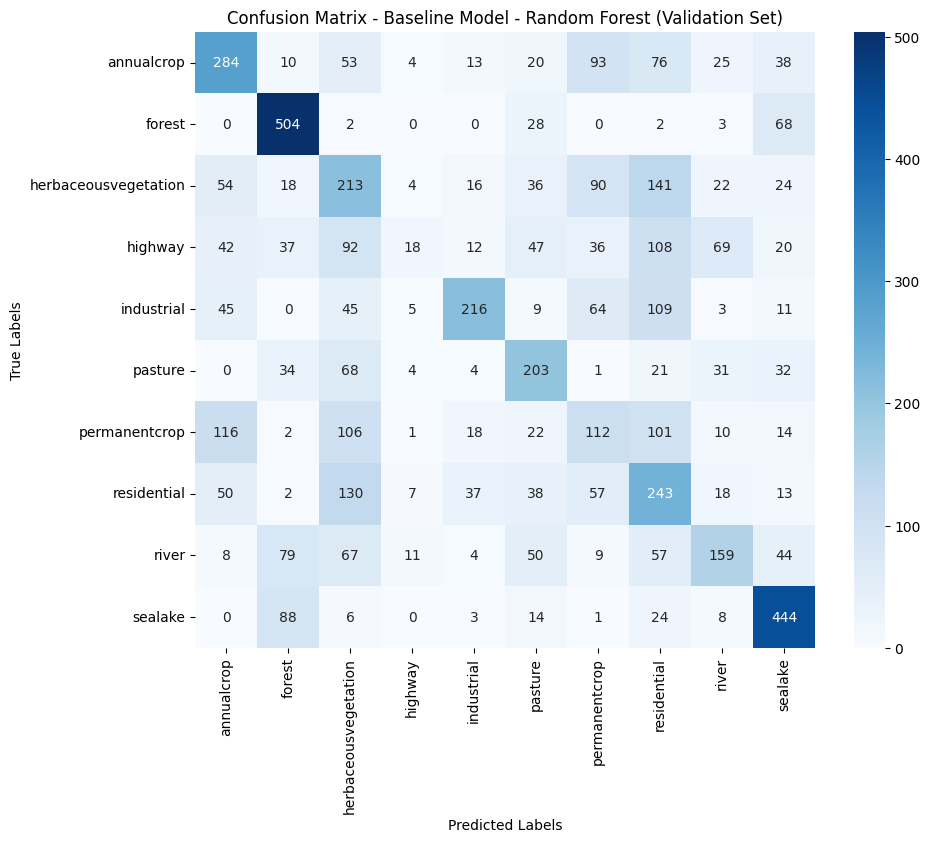

In [14]:
# Task 3: Calculate confusion matrix

cm = confusion_matrix(y_val, y_val_pred)

# Retrieve class names (ordered as per LabelEncoder)
class_names = encoder.classes_  # This maps 0-9 to original labels

# Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Baseline Model - Random Forest (Validation Set)")
plt.show()


Comment on model accuracy on training vs. validation data: [YOUR ANSWER HERE]

 - Training accuracy score is <u>(0.48)</u>. 
 - Validation accuracy is <u>(0.44)</u>. 
 - While accuracy socres are low, there is no evidence of overfitting as the accuracy scores are close enough.


Does the model generalize well?: [YOUR ANSWER HERE]

 - The model has somewhat low accuracy scores for **both training and validation** datasets. However, given the accuracy, the **model <u>generalizes reasonably well</u> in the sense that validation accuracy <u>(0.44)</u> is only moderately lower than that of training <u>(0.48)</u>**. 

In [15]:
##### For classes that the model performed poorly, I also calculate the recall and precision scores using teh sklearn methods. 

from sklearn.metrics import precision_score, recall_score, classification_report

# Compute precision and recall for each class
precision = precision_score(y_val, y_val_pred, average=None)  # One value per class
recall = recall_score(y_val, y_val_pred, average=None)  # One value per class

# Display results
print("Precision per class:")
for cls, prec in zip(class_names, precision):
    print(f"{cls}: {prec:.4f}")

print("\nRecall per class:")
for cls, rec in zip(class_names, recall):
    print(f"{cls}: {rec:.4f}")


Precision per class:
annualcrop: 0.4741
forest: 0.6512
herbaceousvegetation: 0.2724
highway: 0.3333
industrial: 0.6687
pasture: 0.4347
permanentcrop: 0.2419
residential: 0.2755
river: 0.4569
sealake: 0.6271

Recall per class:
annualcrop: 0.4610
forest: 0.8303
herbaceousvegetation: 0.3447
highway: 0.0374
industrial: 0.4260
pasture: 0.5101
permanentcrop: 0.2231
residential: 0.4084
river: 0.3258
sealake: 0.7551


Comment on the classes that the model confuses the most: [YOUR ANSWER HERE]

 - The class label the model confuses the most is **highway**. From the confusion matrix, we can see that in the validation dataset, only **18** true highway were correctly predicted out of **481** (true) examples. **Recall = 0.037**.
 - **Permanent crop** is the next class that the model confuses the most. Only **112** were correctly predicted out of **502**. **Recall = 0.22**.
 - In terms of precision, permanent crop is also the class with lowest score **0.24**, followed by herbaceous vegetation **0.272**, and then residential **0.2755**.

#### <span style="color:chocolate"> Exercise 7 (20 points) </span>

Implement a Decision Forest classifier that improves the training and validation set accuracy performance of the baseline model implemented above by at least 10% (the more you can improve the better). Also, the performance difference between the training and validation sets should be at most 10%. Be sure to follow these guidelines: 
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> or the <span style="color:chocolate">GradientBoostingClassifier</span> available in the <span style="color:chocolate">sklearn.ensemble</span> module
- Be explicit on how your implementation is different compared to the baseline classifier:
    - different argment values for the baseline model (RandomForestClassifier)?
    - different Decision Forest classifier?
    - different data preprocessing procedure?
    - a combination of the three points above
    - anything else?
- Train the model on (X_train_re, y_train) data.
- Evaluate the model's accuracy on (X_val_re, y_val) data. Comment on training vs. validation performance relative to baseline model.
- Plot confusion matrix using the (y_val, y_val_pred) data. Comment on the classes the model confuses the most relative to the baseline.

#### In answering Ex 7, I tried 
 1. **rf_clf2**, in which I manually tune the parameters.
 2. Gradient boosting, which took too long and I discarded this model.
 3. <u>**Preferred Model**</u>. A third random forest model **rf_clf3**, in which I tried different data prepcocessing and different model parameters.

##### EX 7 Attempt 1: Experimenting with rf_clf2

In [16]:
### YOUR CODE HERE ###


# Improved RandomForestClassifier with optimized hyperparameters
rf_clf2 = ensemble.RandomForestClassifier(
    n_estimators=20,       # More trees 
    max_depth=14,         # Deeper trees to capture more complex patterns
    min_samples_split=100,  # Prevents overfitting 
    min_samples_leaf=50,   # Prevents small leaves
    max_features='log2',  # Randomly selects features per tree (log_2(12288) being the max)
    random_state=7,       # 
    n_jobs=-1             # Uses all available CPU cores
)

# Train the model
rf_clf2.fit(X_train_re, y_train)

# Predict on train and validation sets
y_train_pred2 = rf_clf2.predict(X_train_re)
y_val_pred2 = rf_clf2.predict(X_val_re)

# Compute accuracy
train_acc2 = accuracy_score(y_train, y_train_pred2)
val_acc2 = accuracy_score(y_val, y_val_pred2)

# Print outs
print(f"Improved Model - Training Accuracy: {train_acc2:.3f}")
print(f"Improved Model - Validation Accuracy: {val_acc2:.3f}")
print(f"Performance Gap (Train - Val): {train_acc2 - val_acc2:.3f}")


Improved Model - Training Accuracy: 0.626
Improved Model - Validation Accuracy: 0.572
Performance Gap (Train - Val): 0.054


#### EX 7 Attempt 2: rf_clf3 - Trying different data preprocessing

In [17]:

# Trying different splits 
split = (0.75, 0.15, 0.1)

# create train, val, test sets
X_train, y_train, X_val, y_val, X_test, y_test = split_data(images, encoded_labels, split)

# create train, val, test sets
X_train, y_train, X_val, y_val, X_test, y_test = split_data(images, encoded_labels, split)

# print shapes to double check
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)

print('Shape of val images ', X_val.shape)
print('Shape of train labels ', y_val.shape)

print('Shape of test images ', X_test.shape)
print('Shape of test labels ', y_test.shape)

Shape of train images  (20250, 64, 64, 3)
Shape of train labels  (20250,)
Shape of val images  (4050, 64, 64, 3)
Shape of train labels  (4050,)
Shape of test images  (2700, 64, 64, 3)
Shape of test labels  (2700,)


In [18]:
X_train, y_train = data_preprocessing(X_train, y_train, data_partition='train')
X_val, y_val = data_preprocessing(X_val, y_val, data_partition='val')
X_test, y_test = data_preprocessing(X_test, y_test, data_partition='val')

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val.shape)
print('Shape of test images ', X_test.shape)

2025-03-03 01:38:12.582017: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1990656000 exceeds 10% of free system memory.
2025-03-03 01:38:12.733410: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1990656000 exceeds 10% of free system memory.


Shape of train images  (40500, 64, 64, 3)
Shape of train labels  (40500,)
Shape of val images  (4050, 64, 64, 3)
Shape of test images  (2700, 64, 64, 3)


In [19]:
# After splitting differently, I need to do the preprocessing again and reshape the data like I did for the baseline model
# compute number of features (multiply RGB features)
features_shape = X_train[:, :, :, 0].shape[1] * X_train.shape[2] * X_train.shape[3]
print('Total number of features used for Decision Forests', features_shape)

# reshape data
X_train_re = X_train.reshape(X_train.shape[0], features_shape)
X_val_re = X_val.reshape(X_val.shape[0], features_shape)
X_test_re = X_test.reshape(X_test.shape[0], features_shape)

# print shapes
print('Shape of train images ', X_train_re.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val_re.shape)
print('Shape of test images ', X_test_re.shape)

Total number of features used for Decision Forests 12288
Shape of train images  (40500, 12288)
Shape of train labels  (40500,)
Shape of val images  (4050, 12288)
Shape of test images  (2700, 12288)


In [20]:
# Improved RandomForestClassifier with optimized hyperparameters
rf_clf3 = ensemble.RandomForestClassifier(
    n_estimators=31,       # More trees 
    max_depth=16,         # Deeper trees to capture more complex patterns
    min_samples_split=80,  # Prevents overfitting 
    min_samples_leaf=45,   # Prevents small leaves
    max_features='sqrt',  # Randomly selects features per tree (Settled on sqrt after trying log2)
    random_state=7,       # For reproducibility
    n_jobs=-1             # Uses all available CPU cores
)

# Train the model
rf_clf3.fit(X_train_re, y_train)

# Predict on train and validation sets
y_train_pred3 = rf_clf3.predict(X_train_re)
y_val_pred3 = rf_clf3.predict(X_val_re)

# Compute accuracy
train_acc3 = accuracy_score(y_train, y_train_pred3)
val_acc3 = accuracy_score(y_val, y_val_pred3)

print(f"Preferred Model - Training Accuracy: {train_acc3:.3f}")
print(f"Preferred Model - Validation Accuracy: {val_acc3:.3f}")
print(f"Performance Gap (Train - Val): {train_acc3 - val_acc3:.3f}")


Preferred Model - Training Accuracy: 0.683
Preferred Model - Validation Accuracy: 0.599
Performance Gap (Train - Val): 0.084


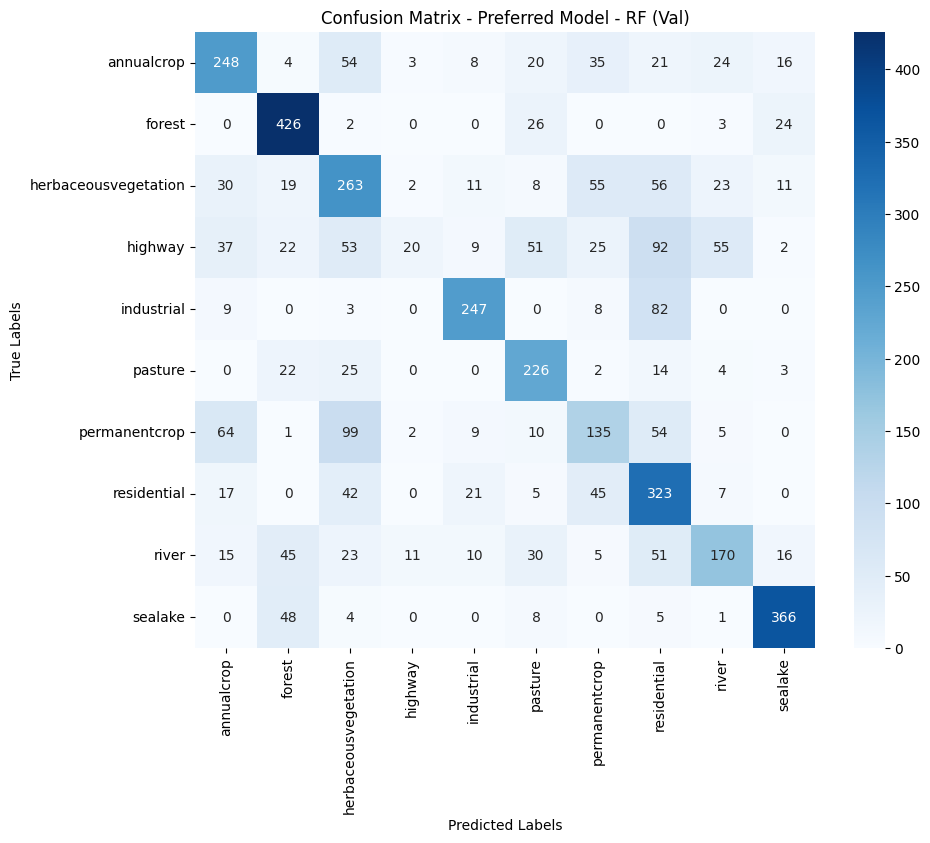

In [21]:
# Confusion matrix for the preferred model

cm = confusion_matrix(y_val, y_val_pred3)

# Retrieve class names (ordered as per LabelEncoder)
class_names = encoder.classes_  # This maps 0-9 to original labels

# Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Preferred Model - RF (Val)")
plt.show()


In [22]:
precision3 = precision_score(y_val, y_val_pred3, average=None)  # One value per class
recall3 = recall_score(y_val, y_val_pred3, average=None)  # One value per class

# Retrieve class names from LabelEncoder
#class_names = encoder.classes_

# Display results
print('Metrics for the preferred rf model')
print(60*'-')
print("Precision per class:\n")
for cls, prec in zip(class_names, precision3):
    print(f"{cls}: {prec:.3f}")

print(50*'-')
print("Recall per class:\n")
for cls, rec in zip(class_names, recall3):
    print(f"{cls}: {rec:.3f}")


Metrics for the preferred rf model
------------------------------------------------------------
Precision per class:

annualcrop: 0.590
forest: 0.726
herbaceousvegetation: 0.463
highway: 0.526
industrial: 0.784
pasture: 0.589
permanentcrop: 0.435
residential: 0.463
river: 0.582
sealake: 0.836
--------------------------------------------------
Recall per class:

annualcrop: 0.573
forest: 0.886
herbaceousvegetation: 0.550
highway: 0.055
industrial: 0.708
pasture: 0.764
permanentcrop: 0.356
residential: 0.702
river: 0.452
sealake: 0.847


##### Ex 7 Attempt 3 - gradient boosting - gave up after some trials.

##### How your implementation is different compared to the baseline classifier: [YOUR ANSWER HERE]

Among the various implementations I experimented, I present the preferred model: 

 - n-estimators = 31 (compared with 2 trees in baseline)
 - max_depth = 16 (max tree depth 8 in baseline)
 - min_sample_split = 80 (no split if node contains less than 80 samples)
 - min_sample_leaf = 45 (no split if it will result in a node with less than 45 samples)
 - n_jobs = -1 (using all cores. My code is running in GitHub Codespace)

 - splits = (0.75, 0.15, 0.1) 
 - also tried max_features = 'log2' in which case the max number of features is $\log_2(12288)$. But 'sqrt' is preferred.

Comment on training vs. validation performance relative to baseline model: [YOUR ANSWER HERE]

Again here I will compare the preferred model with the baseline

Model | Training accuracy | Validation Accuracy | Performance Gap (Train - Val) | 
-|-|-|-|
 Baseline | 0.479 | 0.444 | 0.034 | 
 **Preferred** | 0.683 | 0.599 | 0.084 |
 Improvement (preferred metric - baseline - metric) | 0.204 | 0.155 | -0.05 |


Comment on the classes the model confuses the most relative to the baseline: [YOUR ANSWER HERE]

Based on the confusion matrix (displayed above) for the preferred model, and based on the print outs listed below: 

 - In terms of recall, the worst performing class is still **highway**, with recall = 0.055 (0.037 in baseline). Highway is followed by pernanent crop.
 - In terms of precision, the worst performing class is **permanent crop**, with precision = 0.044. It's followed by residential and herbaceous vegetation (tie) as the second worst performing labels.
**Metrics for the preferred rf model**

 - Precision per class:

   - annualcrop: 0.590

   - forest: 0.726

   - herbaceousvegetation: 0.463

   - highway: 0.526

   - industrial: 0.784

   - pasture: 0.589

   - permanentcrop: 0.435

   - residential: 0.463

   - river: 0.582

   - sealake: 0.836

 - Recall per class:

   - annualcrop: 0.573

   - forest: 0.886

   - herbaceousvegetation: 0.550

   - highway: 0.055

   - industrial: 0.708

   - pasture: 0.764

   - permanentcrop: 0.356

   - residential: 0.702

   - river: 0.452

   - sealake: 0.847

---
### Step 5: Evaluation and Generalization

#### <span style="color:chocolate"> Exercise 8 (2 points) </span>

Report accuracy performance on the test data using the model trained for Exercise 7. How does the test set performance compare with the one reported for the training and validation sets?

In [23]:
### YOUR CODE HERE ###

# Predict on test data
# Note that rf_clf3 is the preferred model
y_pred = rf_clf3.predict(X_test_re)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy using the preferred RF model: {accuracy:.3f}")

Test Accuracy using the preferred RF model: 0.609


Comment on test set accuracy vs. training vs. validation set accuracy:

 - Accuracy score from the preferred RF model **on test data** is **0.609**.
 - Test accuracy (0.609) is slghtly better than validation accuracy (0.599). A sign of reasonale generalizability, although the overall accuracy is not very high.
 - Test accuracy (0.609) is lower than train accuracy (0.683) by **0.074**. Again, not indicating very poor generalizability.

---
### Step 6: Discussion

#### <span style="color:chocolate"> Exercise 9 (8 points) </span>

Would you recommend a Decision Forest for land cover classification? Why or why not?

### YOUR ANSWER HERE ###

 - I would NOT recommend a Decision Forest model for land cover classification **without first trying out other models**.   
 - The main reason is that, although the trained model exihibits a resonable generalizability, **the overall accuracy scores are low**. And the recall (and to a lesser degree, precision) is quite poor for some classes.
 - That said, I may still use RF models to select features (and to select model).
 

#### <span style="color:chocolate"> Exercise 10 (10 points) </span>

What other ML model would you propose to improve performance over the Decision Forest classifier you implemented for Exercise 7?

### YOUR ANSWER HERE ###

 - Based on previous homework assignments and lecture contents, I would propose trying Neural Network models to carry out this classification task. At least as an experiment to see if NN models would perform better on accuracy, recall, and precision.
 - Specifiically, I would propose to use multinomial logit (softmax) as the final layer activation, mapping the prediction values for each example into a probability space ($\sum P_i 
 = 1$).
 - Hidden layers can be added because they may able to capture patterns at different scales, so that different useful land surface features may be captured by the NN model.

----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Implement the idea proposed for Exercise 10. Perform hyperparameter tuning using the training and validation sets, then report the model performance on the test data. Does your model generalize well?

In [24]:
### YOUR CODE HERE ###